In [1]:
# Justin Hawk
# 3/36/2026
# UniqueAxis3DCG.ipynb
# Axis independent heads

import fennec_ml as fn
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import json
from torch.utils.data import TensorDataset, DataLoader
import glob
import re

# --- FOLDER CONFIG ---
data_dir = os.path.join(os.getcwd(), "testing_data")
os.makedirs(data_dir, exist_ok=True)

excel_dir = r"C:\Project_FENNEC\FENNEC-25_26\Justin_Hawk\DATA\raw_3D_data"
csv_dir = r"C:\Project_FENNEC\FENNEC-25_26\Justin_Hawk\DATA\processed_data"

# --- MAKE VARS OF INTEREST ---
base_dir = os.getcwd()
json_path = os.path.join(base_dir, "3D_vars_of_interest.json")

# Data to write
vars_of_interest = {
    "IMU_0": ['GyrX', 'GyrY', 'GyrZ', 'AccX', 'AccY', 'AccZ'],
    #"RCOU": ['C1','C2','C3','C4'],
    #"ATT": ["Roll","Pitch","Yaw"],
    #"ATT": ["DesRoll","Roll","DesPitch","Pitch","DesYaw","Yaw","ErrRP","ErrYaw"],
    #"RATE": ["RDes","R","ROut","PDes","P","POut","YDes","Y","YOut"], # Not sure but could have been 88% acuracy
    #"VIBE_0": ["VibeX", "VibeY", "VibeZ"],
    #"VIBE_1": ["VibeX", "VibeY", "VibeZ"]
}

# Write to JSON file
with open(json_path, "w") as f:
    json.dump(vars_of_interest, f, indent=4)

print(f"Created {json_path}")

Created c:\Project_FENNEC\FENNEC-25_26\Justin_Hawk\FENNEC_3D_Code\3D_vars_of_interest.json


In [289]:
# --- EXCEL TO CSV ---
print("Using folder_cleaner() to convert from raw excel files to useful .csv's.\nfolder_cleaner() output:")

print("Running folder_cleaner...")
fn.folder_cleaner(excel_dir, csv_dir, overwrite= True, varspath="3D_vars_of_interest.json", downsample=False)
print("folder_cleaner finished")

Using folder_cleaner() to convert from raw excel files to useful .csv's.
folder_cleaner() output:
Running folder_cleaner...
299G_APT_L_1.xlsx processed and saved to C:\Project_FENNEC\FENNEC-25_26\Justin_Hawk\DATA\processed_data as 299G_APT_L_1.csv
300G_APT_L_2.xlsx processed and saved to C:\Project_FENNEC\FENNEC-25_26\Justin_Hawk\DATA\processed_data as 300G_APT_L_2.csv
301G_APT_L_3.xlsx processed and saved to C:\Project_FENNEC\FENNEC-25_26\Justin_Hawk\DATA\processed_data as 301G_APT_L_3.csv
302G_APT_L_4.xlsx processed and saved to C:\Project_FENNEC\FENNEC-25_26\Justin_Hawk\DATA\processed_data as 302G_APT_L_4.csv
320G_FSN_M_1.xlsx processed and saved to C:\Project_FENNEC\FENNEC-25_26\Justin_Hawk\DATA\processed_data as 320G_FSN_M_1.csv
321G_FSN_M_2.xlsx processed and saved to C:\Project_FENNEC\FENNEC-25_26\Justin_Hawk\DATA\processed_data as 321G_FSN_M_2.csv
322G_FSN_M_3.xlsx processed and saved to C:\Project_FENNEC\FENNEC-25_26\Justin_Hawk\DATA\processed_data as 322G_FSN_M_3.csv
323G_FSN

In [2]:
from utils.data_preprocess_3axis import Flight_Objects, FlightDataNormalizer, FlightDataSegmenter
from utils.data_preprocess_3axis import split_flights_by_class, make_dataloader
#labels = Get_3D_Labels_Updated(csv_dir)

# flight objects
flight_splitter = Flight_Objects(csv_dir)

#data and labels
all_data, all_labels_x, all_labels_y, all_labels_z = flight_splitter.get_data_and_labels()
#print(all_data)
print("X labels:", all_labels_x)
print("Y labels:", all_labels_y)
print("Z labels:", all_labels_z)

train_flights, val_flights, test_flights = split_flights_by_class(flight_splitter,train_per_class=3, val_per_class=0)
print(f"Number of training flights: {len(train_flights)}")
print(f"Number of val flights: {len(val_flights)}")
print(f"Number of testing flights: {len(test_flights)}")

# Data normilzer
normalizer = FlightDataNormalizer()

# Fit norm on train data, then apply to val/test
train_flights = normalizer.fit_transform(train_flights)

# Transfrom to Val/Test
val_flights = normalizer.transform(val_flights)
test_flights = normalizer.transform(test_flights)

segment_length = 50

# Smallest full-segment flight in training set
train_min_segments_per_flight = min(
    f.data.shape[0] // segment_length
    for f in train_flights
    if f.data.shape[0] // segment_length > 0
)

# Smallest full-segment flight in testing set
test_min_segments_per_flight = min(
    f.data.shape[0] // segment_length
    for f in test_flights
    if f.data.shape[0] // segment_length > 0
)

print("Smallest full-segment flight in training set:", train_min_segments_per_flight)
print("Smallest full-segment flight in testing set:", test_min_segments_per_flight)

# Use separate segmenters so each split is internally balanced
train_segmenter = FlightDataSegmenter(
    segment_length=segment_length,
    max_segments_per_flight=train_min_segments_per_flight,
    seed=42
)

test_segmenter = FlightDataSegmenter(
    segment_length=segment_length,
    max_segments_per_flight=test_min_segments_per_flight,
    seed=42
)

train_segments, train_labels_x, train_labels_y, train_labels_z = train_segmenter.segment_flights(train_flights)
test_segments, test_labels_x, test_labels_y, test_labels_z = test_segmenter.segment_flights(test_flights)

# Check shapes
print("Train segments:", train_segments.shape)
print("Train X labels:", train_labels_x.shape)
print("Train Y labels:", train_labels_y.shape)
print("Train Z labels:", train_labels_z.shape)
#print("Validation segments:", val_segments.shape)
print("Test segments:", test_segments.shape)

# Data loaders
batch_size = 32

train_loader = make_dataloader(
    train_segments,
    train_labels_x,
    train_labels_y,
    train_labels_z,
    batch_size=batch_size,
    shuffle=True
)

test_loader = make_dataloader(
    test_segments,
    test_labels_x,
    test_labels_y,
    test_labels_z,
    batch_size=batch_size,
    shuffle=False
)

print(f"Number of batches in train loader: {len(train_loader)}")
#print(f"Number of batches in val loader: {len(val_loader)}")
print(f"Number of batches in test loader: {len(test_loader)}")

X labels: [2, 2, 2, 2, 0, 0, 0, 0, 1, 1, 1, 1]
Y labels: [0, 0, 0, 0, 2, 2, 2, 2, 1, 1, 1, 1]
Z labels: [0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2]
Number of training flights: 9
Number of val flights: 0
Number of testing flights: 3
Scaler fitted: mean shape (6,) var shape (6,)
Scaler fitted on training data:
Feature 0: mean = 0.0209, std = 0.5037
Feature 1: mean = 0.0566, std = 0.3419
Feature 2: mean = 0.0668, std = 0.6797
Feature 3: mean = -1.7962, std = 1.2275
Feature 4: mean = -1.4342, std = 3.5014
Feature 5: mean = -10.2250, std = 2.5446
Smallest full-segment flight in training set: 228
Smallest full-segment flight in testing set: 267
Train segments: (2052, 50, 6)
Train X labels: (2052,)
Train Y labels: (2052,)
Train Z labels: (2052,)
Test segments: (801, 50, 6)
Number of batches in train loader: 65
Number of batches in test loader: 26


In [3]:
print("Train full segments per flight:")
for i, f in enumerate(train_flights):
    print(f"Flight {i}: {f.data.shape[0] // segment_length}")

print("\nTest full segments per flight:")
for i, f in enumerate(test_flights):
    print(f"Flight {i}: {f.data.shape[0] // segment_length}")

Train full segments per flight:
Flight 0: 405
Flight 1: 368
Flight 2: 239
Flight 3: 228
Flight 4: 246
Flight 5: 297
Flight 6: 392
Flight 7: 393
Flight 8: 372

Test full segments per flight:
Flight 0: 317
Flight 1: 267
Flight 2: 376


In [4]:
import numpy as np

# X_train_segments is your list/array of training segments (num_segments, seq_len, num_features)
X_train = np.concatenate(train_segments, axis=0)  # flatten over segments

# Compute per-feature mean and std
feature_means = X_train.mean(axis=0)
feature_stds  = X_train.std(axis=0)

print("Per-feature mean after normalization:", feature_means)
print("Per-feature std after normalization:", feature_stds)

# Overall mean/std
print("Overall mean:", X_train.mean())
print("Overall std:", X_train.std())

Per-feature mean after normalization: [-0.00372893  0.0098467  -0.02387426 -0.02907543  0.00293731 -0.01407941]
Per-feature std after normalization: [1.00466265 1.05977138 1.01201513 1.02774716 1.01957899 1.04126652]
Overall mean: -0.009662334602315118
Overall std: 1.0277687348901121


In [5]:
from collections import Counter

print("Train X distribution:", Counter(train_labels_x))
print("Train Y distribution:", Counter(train_labels_y))
print("Train Z distribution:", Counter(train_labels_z))

print("Test X distribution:", Counter(test_labels_x))
print("Test Y distribution:", Counter(test_labels_y))
print("Test Z distribution:", Counter(test_labels_z))

Train X distribution: Counter({np.int64(2): 684, np.int64(0): 684, np.int64(1): 684})
Train Y distribution: Counter({np.int64(0): 684, np.int64(2): 684, np.int64(1): 684})
Train Z distribution: Counter({np.int64(0): 684, np.int64(1): 684, np.int64(2): 684})
Test X distribution: Counter({np.int64(2): 267, np.int64(0): 267, np.int64(1): 267})
Test Y distribution: Counter({np.int64(0): 267, np.int64(2): 267, np.int64(1): 267})
Test Z distribution: Counter({np.int64(0): 267, np.int64(1): 267, np.int64(2): 267})


In [6]:
import torch
import torch.nn as nn

class AxisWiseLSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.3):
        super().__init__()

        lstm_dropout = dropout if num_layers > 1 else 0.0

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout
        )

        self.dropout = nn.Dropout(p=dropout)

        # Three output heads: X, Y, Z
        self.fc_x = nn.Linear(hidden_size, 3)  # F, M, A
        self.fc_y = nn.Linear(hidden_size, 3)  # P, C, S
        self.fc_z = nn.Linear(hidden_size, 3)  # T, N, B

    def forward(self, x):
        # x: (batch, timesteps, features)
        out, (hn, cn) = self.lstm(x)

        # final hidden state from last LSTM layer
        last_hidden = hn[-1]   # shape: (batch, hidden_size)
        last_hidden = self.dropout(last_hidden)

        logits_x = self.fc_x(last_hidden)
        logits_y = self.fc_y(last_hidden)
        logits_z = self.fc_z(last_hidden)

        return logits_x, logits_y, logits_z

In [7]:
input_size = 6
num_layers = 2
hidden_size = 20
epochs = 40

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

axis_model = AxisWiseLSTMClassifier(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout=0.3
).to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    axis_model.parameters(),
    lr=0.001,
    weight_decay=0
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=10
)

In [8]:
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_samples = 0

    total_correct_x = 0
    total_correct_y = 0
    total_correct_z = 0
    total_correct_full = 0

    with torch.no_grad():
        for X_batch, yx_batch, yy_batch, yz_batch in loader:
            X_batch = X_batch.to(device)
            yx_batch = yx_batch.to(device)
            yy_batch = yy_batch.to(device)
            yz_batch = yz_batch.to(device)

            logits_x, logits_y, logits_z = model(X_batch)

            loss_x = loss_fn(logits_x, yx_batch)
            loss_y = loss_fn(logits_y, yy_batch)
            loss_z = loss_fn(logits_z, yz_batch)
            loss = (loss_x + loss_y + loss_z) / 3

            bs = X_batch.size(0)
            total_loss += loss.item() * bs
            total_samples += bs

            pred_x = logits_x.argmax(dim=1)
            pred_y = logits_y.argmax(dim=1)
            pred_z = logits_z.argmax(dim=1)

            total_correct_x += (pred_x == yx_batch).sum().item()
            total_correct_y += (pred_y == yy_batch).sum().item()
            total_correct_z += (pred_z == yz_batch).sum().item()

            full_correct = ((pred_x == yx_batch) &
                            (pred_y == yy_batch) &
                            (pred_z == yz_batch)).sum().item()
            total_correct_full += full_correct

    avg_loss = total_loss / total_samples
    acc_x = total_correct_x / total_samples
    acc_y = total_correct_y / total_samples
    acc_z = total_correct_z / total_samples
    acc_full = total_correct_full / total_samples

    return avg_loss, acc_x, acc_y, acc_z, acc_full

In [11]:
import os
import torch

save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

best_test_full_acc = -1.0
best_epoch = -1
best_path = os.path.join(save_dir, "best_axis_model_fullacc.pth")

for epoch in range(epochs):
    axis_model.train()

    total_loss = 0.0
    total_samples = 0

    total_correct_x = 0
    total_correct_y = 0
    total_correct_z = 0
    total_correct_full = 0

    for X_batch, yx_batch, yy_batch, yz_batch in train_loader:
        X_batch = X_batch.to(device)
        yx_batch = yx_batch.to(device)
        yy_batch = yy_batch.to(device)
        yz_batch = yz_batch.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits_x, logits_y, logits_z = axis_model(X_batch)

        loss_x = loss_fn(logits_x, yx_batch)
        loss_y = loss_fn(logits_y, yy_batch)
        loss_z = loss_fn(logits_z, yz_batch)
        loss = (loss_x + loss_y + loss_z) / 3

        loss.backward()
        optimizer.step()

        batch_size = X_batch.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        pred_x = logits_x.argmax(dim=1)
        pred_y = logits_y.argmax(dim=1)
        pred_z = logits_z.argmax(dim=1)

        total_correct_x += (pred_x == yx_batch).sum().item()
        total_correct_y += (pred_y == yy_batch).sum().item()
        total_correct_z += (pred_z == yz_batch).sum().item()

        full_correct = ((pred_x == yx_batch) &
                        (pred_y == yy_batch) &
                        (pred_z == yz_batch)).sum().item()
        total_correct_full += full_correct

    avg_train_loss = total_loss / total_samples
    train_acc_x = total_correct_x / total_samples
    train_acc_y = total_correct_y / total_samples
    train_acc_z = total_correct_z / total_samples
    train_acc_full = total_correct_full / total_samples

    avg_test_loss, test_acc_x, test_acc_y, test_acc_z, test_acc_full = evaluate(
        axis_model, test_loader, loss_fn, device
    )

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train X: {train_acc_x:.4f} | "
        f"Train Y: {train_acc_y:.4f} | "
        f"Train Z: {train_acc_z:.4f} | "
        f"Train Full: {train_acc_full:.4f} | "
        f"Test Loss: {avg_test_loss:.4f} | "
        f"Test X: {test_acc_x:.4f} | "
        f"Test Y: {test_acc_y:.4f} | "
        f"Test Z: {test_acc_z:.4f} | "
        f"Test Full: {test_acc_full:.4f}"
    )

    if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step(avg_test_loss)
    else:
        scheduler.step()

    test_acc_full = float(test_acc_full)

    if test_acc_full > best_test_full_acc:
        best_test_full_acc = test_acc_full
        best_epoch = epoch + 1
        torch.save(axis_model.state_dict(), best_path)
        print(f"✅ Best model saved (Epoch {best_epoch}, Test Full Acc: {best_test_full_acc:.4f})")
    else:
        print(f"(not saved) best so far: {best_test_full_acc:.4f} @ epoch {best_epoch}")

print("\nLoading best model for final evaluation...")

axis_model.load_state_dict(torch.load(best_path, map_location=device))
axis_model.to(device)
axis_model.eval()

Epoch [1/40] | Train Loss: 0.1677 | Train X: 0.9366 | Train Y: 0.9366 | Train Z: 0.9366 | Train Full: 0.9347 | Test Loss: 0.1747 | Test X: 0.9451 | Test Y: 0.9438 | Test Z: 0.9451 | Test Full: 0.9438
✅ Best model saved (Epoch 1, Test Full Acc: 0.9438)
Epoch [2/40] | Train Loss: 0.1756 | Train X: 0.9288 | Train Y: 0.9293 | Train Z: 0.9288 | Train Full: 0.9254 | Test Loss: 0.1437 | Test X: 0.9538 | Test Y: 0.9538 | Test Z: 0.9526 | Test Full: 0.9513
✅ Best model saved (Epoch 2, Test Full Acc: 0.9513)
Epoch [3/40] | Train Loss: 0.1659 | Train X: 0.9381 | Train Y: 0.9405 | Train Z: 0.9405 | Train Full: 0.9366 | Test Loss: 0.1122 | Test X: 0.9576 | Test Y: 0.9600 | Test Z: 0.9588 | Test Full: 0.9576
✅ Best model saved (Epoch 3, Test Full Acc: 0.9576)
Epoch [4/40] | Train Loss: 0.1544 | Train X: 0.9430 | Train Y: 0.9440 | Train Z: 0.9425 | Train Full: 0.9396 | Test Loss: 0.1219 | Test X: 0.9588 | Test Y: 0.9588 | Test Z: 0.9588 | Test Full: 0.9563
(not saved) best so far: 0.9576 @ epoch 3
Ep

AxisWiseLSTMClassifier(
  (lstm): LSTM(6, 20, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc_x): Linear(in_features=20, out_features=3, bias=True)
  (fc_y): Linear(in_features=20, out_features=3, bias=True)
  (fc_z): Linear(in_features=20, out_features=3, bias=True)
)

In [12]:
avg_test_loss, test_acc_x, test_acc_y, test_acc_z, test_acc_full = evaluate(
    axis_model, test_loader, loss_fn, device)

print(
    f"\nBest Model Results | "
    f"Test Loss: {avg_test_loss:.4f} | "
    f"Test X: {test_acc_x:.4f} | "
    f"Test Y: {test_acc_y:.4f} | "
    f"Test Z: {test_acc_z:.4f} | "
    f"Test Full: {test_acc_full:.4f}"
)


Best Model Results | Test Loss: 0.0844 | Test X: 0.9763 | Test Y: 0.9775 | Test Z: 0.9775 | Test Full: 0.9763


In [13]:
import torch
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_axis_confusion_and_confidence(model, loader, axis="x", device="cpu"):
    """
    Plot normalized confusion matrix and confidence matrix for one axis of an axis-wise model.

    Args:
        model: trained AxisWiseLSTMClassifier
        loader: DataLoader returning (X, yx, yy, yz)
        axis: "x", "y", or "z"
        device: "cpu" or "cuda"
    """

    axis = axis.lower()

    if axis == "x":
        classes = ["F", "M", "A"]
        axis_idx = 0
        axis_name = "X-axis"
    elif axis == "y":
        classes = ["P", "C", "S"]
        axis_idx = 1
        axis_name = "Y-axis"
    elif axis == "z":
        classes = ["T", "N", "B"]
        axis_idx = 2
        axis_name = "Z-axis"
    else:
        raise ValueError("axis must be 'x', 'y', or 'z'")

    model.to(device)
    model.eval()

    all_true = []
    all_preds = []
    all_confidences = []

    with torch.no_grad():
        for X_batch, yx_batch, yy_batch, yz_batch in loader:
            X_batch = X_batch.to(device)
            yx_batch = yx_batch.to(device)
            yy_batch = yy_batch.to(device)
            yz_batch = yz_batch.to(device)

            logits_x, logits_y, logits_z = model(X_batch)

            if axis_idx == 0:
                logits = logits_x
                y_true = yx_batch
            elif axis_idx == 1:
                logits = logits_y
                y_true = yy_batch
            else:
                logits = logits_z
                y_true = yz_batch

            probs = F.softmax(logits, dim=1)
            confs, preds = torch.max(probs, dim=1)

            all_true.extend(y_true.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_confidences.extend(confs.cpu().numpy())

    all_true = np.array(all_true)
    all_preds = np.array(all_preds)
    all_confidences = np.array(all_confidences)

    accuracy = np.mean(all_true == all_preds)
    print(f"{axis_name} Accuracy: {accuracy:.2%}")

    # ---- Normalized confusion matrix ----
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(all_true, all_preds, normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
    ax.set_title(f"{axis_name} Normalized Confusion Matrix")
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")
    plt.tight_layout()
    plt.show()

    # ---- Confidence matrix ----
    n_classes = len(classes)
    conf_matrix = np.zeros((n_classes, n_classes))

    for t, p, c in zip(all_true, all_preds, all_confidences):
        conf_matrix[t, p] += c

    counts = np.bincount(all_true, minlength=n_classes)
    counts[counts == 0] = 1   # avoid divide-by-zero
    conf_matrix = conf_matrix / counts[:, None]

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt=".2f",
        xticklabels=classes,
        yticklabels=classes,
        cmap="Blues",
        vmin=0,
        vmax=1,
        ax=ax,
        cbar=True
    )

    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")
    ax.set_title(f"{axis_name} Confidence Matrix")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color("black")

    plt.tight_layout()
    plt.show()

X-axis Accuracy: 97.63%


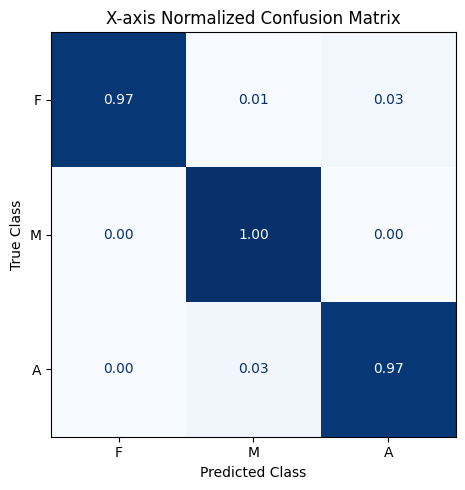

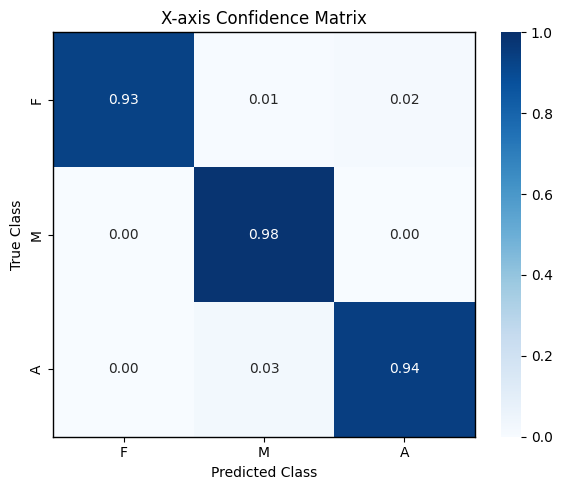

Y-axis Accuracy: 97.75%


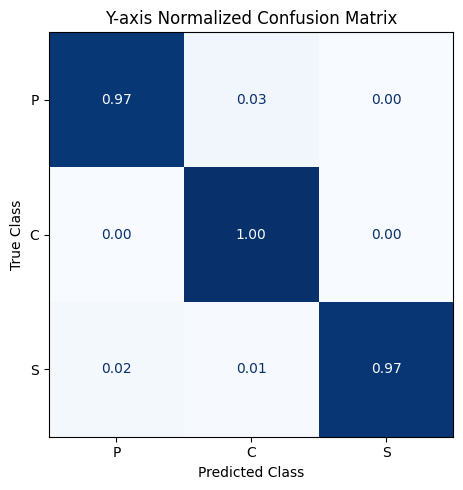

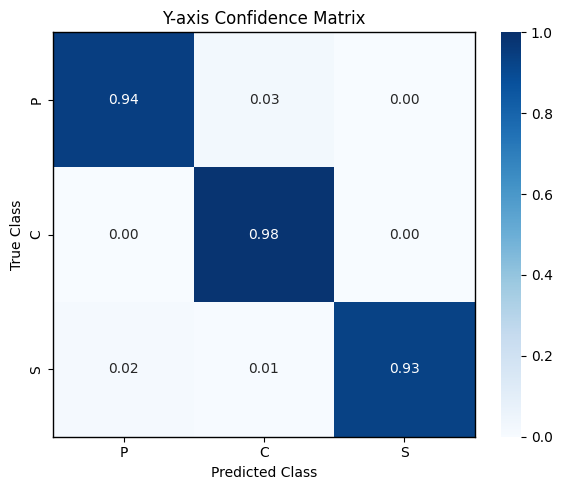

Z-axis Accuracy: 97.75%


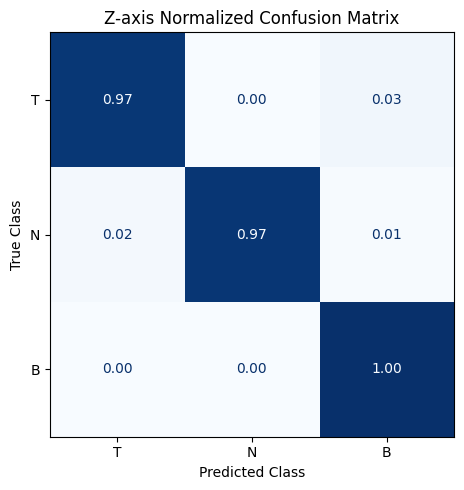

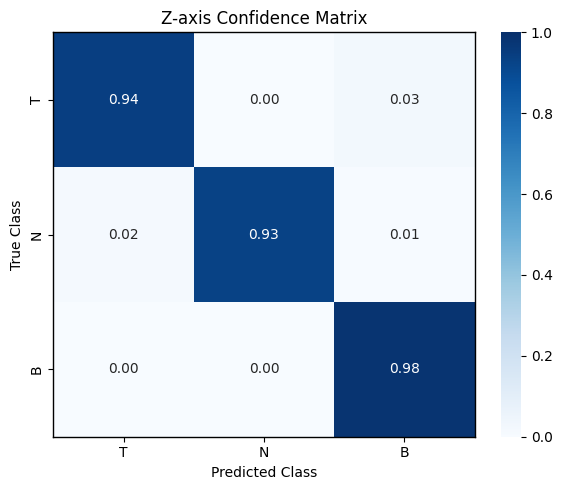

In [14]:
plot_axis_confusion_and_confidence(axis_model, test_loader, axis="x", device=device)
plot_axis_confusion_and_confidence(axis_model, test_loader, axis="y", device=device)
plot_axis_confusion_and_confidence(axis_model, test_loader, axis="z", device=device)

In [15]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def get_segment_predictions_from_loader(model, loader, device="cpu"):
    model.eval()
    model.to(device)

    all_pred_x = []
    all_pred_y = []
    all_pred_z = []

    all_true_x = []
    all_true_y = []
    all_true_z = []

    with torch.no_grad():
        for batch in loader:
            x_batch, yx_batch, yy_batch, yz_batch = batch

            x_batch = x_batch.to(device)
            yx_batch = yx_batch.to(device)
            yy_batch = yy_batch.to(device)
            yz_batch = yz_batch.to(device)

            logits_x, logits_y, logits_z = model(x_batch)

            pred_x = torch.argmax(logits_x, dim=1)
            pred_y = torch.argmax(logits_y, dim=1)
            pred_z = torch.argmax(logits_z, dim=1)

            all_pred_x.extend(pred_x.cpu().numpy())
            all_pred_y.extend(pred_y.cpu().numpy())
            all_pred_z.extend(pred_z.cpu().numpy())

            all_true_x.extend(yx_batch.cpu().numpy())
            all_true_y.extend(yy_batch.cpu().numpy())
            all_true_z.extend(yz_batch.cpu().numpy())

    results = {
        "pred_x": np.array(all_pred_x),
        "pred_y": np.array(all_pred_y),
        "pred_z": np.array(all_pred_z),
        "true_x": np.array(all_true_x),
        "true_y": np.array(all_true_y),
        "true_z": np.array(all_true_z),
    }

    return results

In [16]:
def plot_segment_predictions(results):
    seg_idx = np.arange(len(results["pred_x"]))

    plt.figure(figsize=(10, 4))
    plt.plot(seg_idx, results["pred_x"], marker='o', linestyle='None', label="Pred")
    plt.plot(seg_idx, results["true_x"], linestyle='--', label="True")
    plt.yticks([0,1,2], ['F','M','A'])
    plt.title("X Axis Prediction")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(seg_idx, results["pred_y"], marker='o',linestyle='None', label="Pred")
    plt.plot(seg_idx, results["true_y"], linestyle='--', label="True")
    plt.yticks([0,1,2], ['P','C','S'])
    plt.title("Y Axis Prediction")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(seg_idx, results["pred_z"], marker='o',linestyle='None', label="Pred")
    plt.plot(seg_idx, results["true_z"], linestyle='--', label="True")
    plt.yticks([0,1,2], ['T','N','B'])
    plt.title("Z Axis Prediction")
    plt.legend()
    plt.grid(True)
    plt.show()

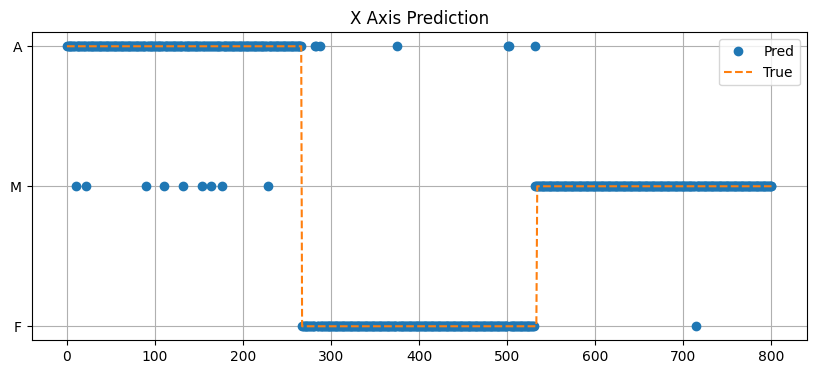

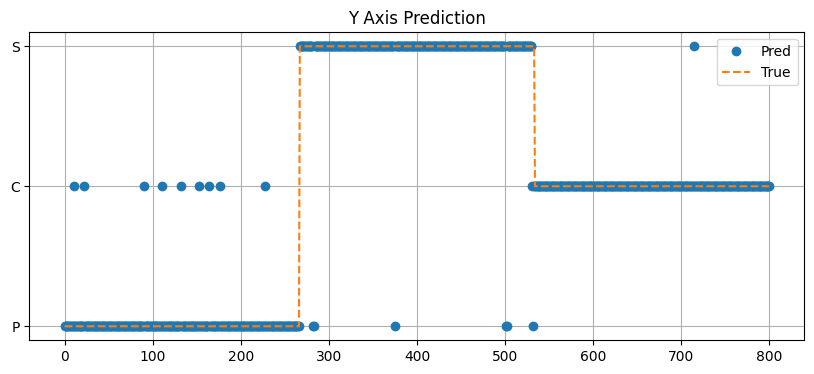

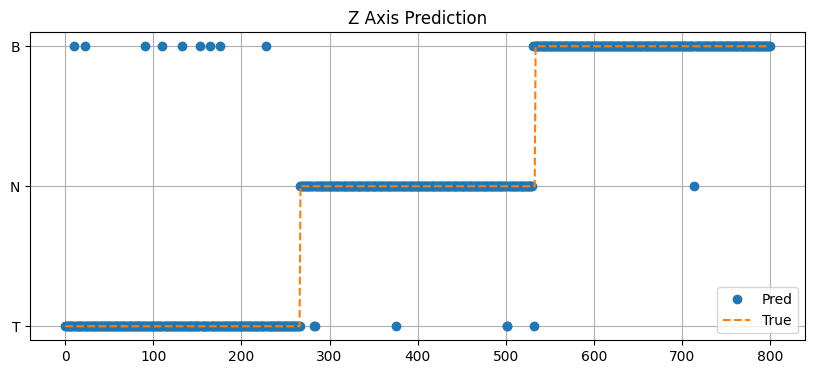

In [17]:
results = get_segment_predictions_from_loader(axis_model, test_loader, device=device)
plot_segment_predictions(results)

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter

def make_axis_video_full_timeline(pred, true, labels, title, save_path,
                                interval=150, step=5):

    n = len(pred)
    seg_idx = np.arange(n)

    fig, ax = plt.subplots(figsize=(10, 4))

    # Prediction: blue dots only
    pred_scatter = ax.scatter([], [], marker='o', linestyle='None', label="Pred")

    # True: dashed line
    true_line, = ax.plot([], [], linestyle='--', color='orange', label="True")

    # Current point highlight
    current_point = ax.scatter([], [], color='red', s=80)

    ax.set_xlim(0, n - 1)
    ax.set_ylim(-0.5, 2.5)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(labels)
    ax.set_xlabel("Segment Index")
    ax.set_title(title)
    ax.grid(True)
    ax.legend()

    def update(frame):
        x_vals = seg_idx[:frame + 1]

        pred_scatter.set_offsets(np.c_[x_vals, pred[:frame + 1]])
        true_line.set_data(x_vals, true[:frame + 1])
        current_point.set_offsets([[frame, pred[frame]]])

        return pred_scatter, true_line, current_point

    ani = FuncAnimation(
        fig,
        update,
        frames=range(0, n, step),
        interval=interval,
        blit=True
    )

    writer = FFMpegWriter(fps=8)
    ani.save(save_path, writer=writer)

    plt.close(fig)
    print(f"Saved: {save_path}")

In [35]:
results = get_segment_predictions_from_loader(axis_model, test_loader, device="cpu")

make_axis_video_full_timeline(
    results["pred_x"],
    results["true_x"],
    ['F', 'M', 'A'],
    "X Axis Prediction",
    "x_axis.mp4"
)

make_axis_video_full_timeline(
    results["pred_y"], results["true_y"],
    ['P', 'C', 'S'],
    "Y Axis Prediction",
    "y_axis.mp4"
)

make_axis_video_full_timeline(
    results["pred_z"], results["true_z"],
    ['T', 'N', 'B'],
    "Z Axis Prediction",
    "z_axis.mp4"
)

Saved: x_axis.mp4
Saved: y_axis.mp4
Saved: z_axis.mp4


In [26]:
import torch
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_full_class_confusion_and_confidence(model, loader, device="cpu"):
    """
    Plot normalized confusion matrix and confidence matrix for the 3 valid
    full CG classes: APT, FSN, MCB.
    """

    classes = ["APT", "FSN", "MCB"]

    model.to(device)
    model.eval()

    all_true = []
    all_preds = []
    all_confidences = []

    with torch.no_grad():
        for X_batch, yx_batch, yy_batch, yz_batch in loader:
            X_batch = X_batch.to(device)
            yx_batch = yx_batch.to(device)
            yy_batch = yy_batch.to(device)
            yz_batch = yz_batch.to(device)

            logits_x, logits_y, logits_z = model(X_batch)

            probs_x = F.softmax(logits_x, dim=1)
            probs_y = F.softmax(logits_y, dim=1)
            probs_z = F.softmax(logits_z, dim=1)

            # X: [0.1, 0.2, 0.7]   → likely A
            # Y: [0.6, 0.3, 0.1]   → likely P
            # Z: [0.8, 0.1, 0.1]   → likely T

            # Class scores:
            # APT -> x=A(2), y=P(0), z=T(0)
            # FSN -> x=F(0), y=S(2), z=N(1)
            # MCB -> x=M(1), y=C(1), z=B(2)
            scores = torch.stack([
                probs_x[:, 2] * probs_y[:, 0] * probs_z[:, 0],  # APT
                probs_x[:, 0] * probs_y[:, 2] * probs_z[:, 1],  # FSN
                probs_x[:, 1] * probs_y[:, 1] * probs_z[:, 2],  # MCB
            ], dim=1)

            #Pick the best full class
            confs, preds = torch.max(scores, dim=1)

            # True class mapping
            true_classes = []
            for i in range(X_batch.size(0)):
                tx = yx_batch[i].item()
                ty = yy_batch[i].item()
                tz = yz_batch[i].item()

                if tx == 2 and ty == 0 and tz == 0:
                    true_classes.append(0)   # APT
                elif tx == 0 and ty == 2 and tz == 1:
                    true_classes.append(1)   # FSN
                elif tx == 1 and ty == 1 and tz == 2:
                    true_classes.append(2)   # MCB
                else:
                    continue

            # Need matching preds/confs for kept entries
            kept_preds = []
            kept_confs = []
            for i in range(X_batch.size(0)):
                tx = yx_batch[i].item()
                ty = yy_batch[i].item()
                tz = yz_batch[i].item()

                if (tx == 2 and ty == 0 and tz == 0) or \
                   (tx == 0 and ty == 2 and tz == 1) or \
                   (tx == 1 and ty == 1 and tz == 2):
                    kept_preds.append(preds[i].item())
                    kept_confs.append(confs[i].item())

            all_true.extend(true_classes)
            all_preds.extend(kept_preds)
            all_confidences.extend(kept_confs)

    all_true = np.array(all_true)
    all_preds = np.array(all_preds)
    all_confidences = np.array(all_confidences)

    accuracy = np.mean(all_true == all_preds)
    print(f"Full CG Class Accuracy: {accuracy:.2%}")

    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(all_true, all_preds, normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
    ax.set_title("Full CG Class Normalized Confusion Matrix")
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")
    plt.tight_layout()
    plt.show()

    n_classes = len(classes)
    conf_matrix = np.zeros((n_classes, n_classes))

    for t, p, c in zip(all_true, all_preds, all_confidences):
        conf_matrix[t, p] += c

    counts = np.bincount(all_true, minlength=n_classes)
    counts[counts == 0] = 1
    conf_matrix = conf_matrix / counts[:, None]

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt=".2f",
        xticklabels=classes,
        yticklabels=classes,
        cmap="Blues",
        vmin=0,
        vmax=1,
        ax=ax,
        cbar=True
    )

    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")
    ax.set_title("Full CG Class Confidence Matrix")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color("black")

    plt.tight_layout()
    plt.show()

Full CG Class Accuracy: 96.75%


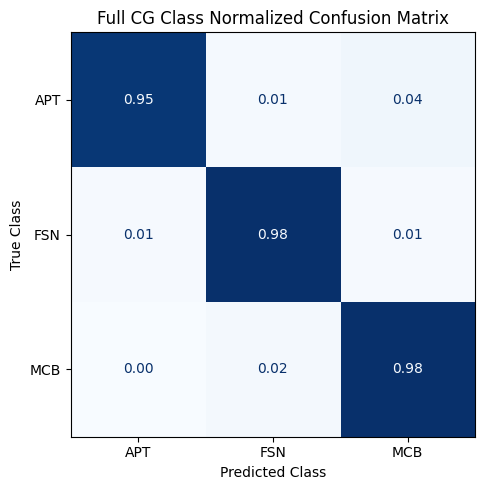

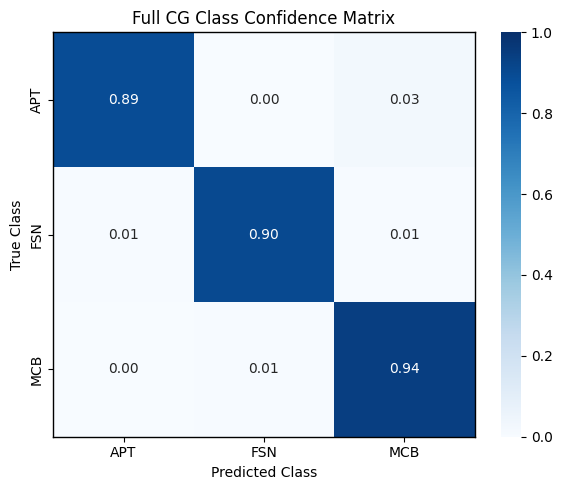

In [78]:
plot_full_class_confusion_and_confidence(axis_model, test_loader, device=device)